# Basic SIR Model History Matching

This notebook demonstrates how to use the history matching library with a stochastic SIR
epidemiological model using the fully automated workflow.

## Overview

History matching is a Bayesian method for model calibration that:
1. Uses statistical emulators to approximate expensive simulations
2. Iteratively reduces the parameter space to "plausible" regions
3. Avoids regions where the model cannot match observed data

We will calibrate a SIR model to synthetic outbreak data to recover the "true" transmission
parameters. For a manual step-by-step workflow, see `02_manual_workflow.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import historymatching as hm
from model import SIR, generate_observed_data

%matplotlib inline
np.random.seed(42)

2026-05-31 15:04:21.033658: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-31 15:04:21.034293: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-31 15:04:21.036410: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-31 15:04:21.042355: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780265061.052030  172360 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780265061.05

/home/cliffk/historymatching/.venv/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


/home/cliffk/historymatching/.venv/lib/python3.12/site-packages/gpflow/versions.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Generate Synthetic "Observed" Data

We create synthetic outbreak data with known parameters that we will try to recover
through history matching.

True parameters we want to recover:
  beta (transmission rate): 1.3
  gamma (recovery rate):    0.5
  R0 (basic reproduction number): 2.60


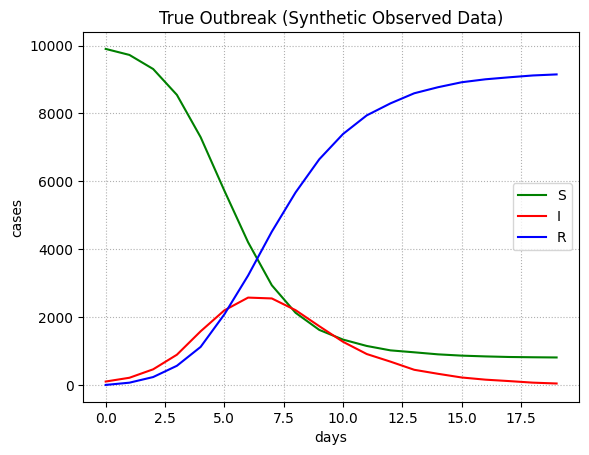

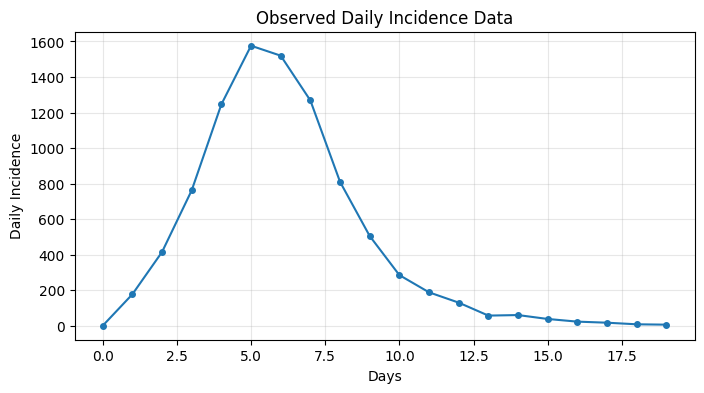

Peak incidence:  1576 cases/day
Total cases:     9091
Attack rate:     90.9%


In [2]:
# "True" parameters that generated our synthetic data
beta_true = 1.3
gamma_true = 0.5
population_size = 10_000
n_seed_infections = 100

print(f"True parameters we want to recover:")
print(f"  beta (transmission rate): {beta_true}")
print(f"  gamma (recovery rate):    {gamma_true}")
print(f"  R0 (basic reproduction number): {beta_true/gamma_true:.2f}")

incidence_obs, true_model = generate_observed_data(
    beta_true=beta_true,
    gamma_true=gamma_true,
    population_size=population_size,
    n_seed_infections=n_seed_infections,
)

true_model.plot("True Outbreak (Synthetic Observed Data)")

plt.figure(figsize=(8, 4))
incidence_obs.plot(style="o-", markersize=4)
plt.xlabel("Days")
plt.ylabel("Daily Incidence")
plt.title("Observed Daily Incidence Data")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Peak incidence:  {incidence_obs.max():.0f} cases/day")
print(f"Total cases:     {incidence_obs.sum():.0f}")
print(f"Attack rate:     {incidence_obs.sum()/population_size:.1%}")

## Define Simulation Function

History matching requires a function that takes a DataFrame of parameter samples
and returns a DataFrame of simulation outputs.

In [3]:
def sir_simulation_function(samples: pd.DataFrame) -> pd.DataFrame:
    """Run SIR model for each row of parameter samples.

    Injects rand_seed for deterministic outputs — the engine filters it
    out before emulation but stores it on result.samples.
    """
    df = samples.copy()
    if 'rand_seed' not in df.columns:
        df['rand_seed'] = np.random.default_rng(42).integers(0, 2**31, size=len(df))

    results = []
    for _, row in df.iterrows():
        model = SIR(
            beta=row["beta"],
            gamma=row["gamma"],
            s0=population_size - n_seed_infections,
            i0=n_seed_infections,
            seed=int(row["rand_seed"]),
        )
        incidence = model.get_incidence()
        result = {f"incidence_{i}": incidence[i] for i in range(len(incidence))}
        result["peak_incidence"] = incidence.max()
        result["total_cases"] = incidence.sum()
        result["attack_rate"] = incidence.sum() / population_size
        results.append(result)
    return pd.DataFrame(results)

# Quick sanity check
test = sir_simulation_function(pd.DataFrame({"beta": [1.0, 1.5], "gamma": [0.3, 0.5]}))
print(f"Simulation output shape: {test.shape}")
print(f"Output columns (first 5): {list(test.columns[:5])}...")

Simulation output shape: (2, 23)
Output columns (first 5): ['incidence_0', 'incidence_1', 'incidence_2', 'incidence_3', 'incidence_4']...


## Configure History Matching Engine

Use the builder pattern to set up the engine. We define:
- **parameter_bounds**: the search space for calibration
- **observations**: the target data as (mean, std) pairs

In [4]:
parameter_bounds = {
    "beta":  (0.5, 3.0),
    "gamma": (0.1, 1.0),
}

observations = {
    "peak_incidence":   (incidence_obs.max(),          50),
    "total_cases":      (incidence_obs.sum(),          200),
    "incidence_5":      (incidence_obs.iloc[5],         30),
    "incidence_10":     (incidence_obs.iloc[10],        40),
    "incidence_15":     (incidence_obs.iloc[15],        20),
}

builder = hm.HistoryMatchingBuilder.from_data(parameter_bounds, observations)
builder.sampling_strategy = "lhs"
builder.emulator_type = "gpr"
builder.n_samples = 500
builder.max_iterations = 4
builder.implausibility_threshold = 3.0
builder.random_seed = 123
engine = builder.build()

engine.set_simulation_function(sir_simulation_function)

print(f"Engine ready. Parameters: {engine.parameter_space.get_parameter_names()}")
print(f"Observations: {list(observations.keys())}")
print(f"Samples per iteration: {engine.n_samples}")
print(f"Max iterations: {engine.max_iterations}")

Engine ready. Parameters: ['beta', 'gamma']
Observations: ['peak_incidence', 'total_cases', 'incidence_5', 'incidence_10', 'incidence_15']
Samples per iteration: 500
Max iterations: 4


/home/cliffk/historymatching/historymatching/builder.py:220: UserWarning: No feature selection specified. Using automatic selection with mean squared z-score.
  warnings.warn("No feature selection specified. Using automatic selection with mean squared z-score.")


## Run Automated History Matching

In [5]:
print("Running automated history matching...")

results = engine.run()

# engine.summary() reports per-wave convergence and the surviving parameter
# ranges in one block — no need to assemble it by hand.
print("\nHistory matching complete!\n")
print(engine.summary())

Running automated history matching...


2026-05-31 15:04:22.907181: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


INFO:historymatching.engine:Checkpoint saved to hm_output/run_20260531_150422/checkpoint.pkl


INFO:historymatching.engine:Wave 1 output saved to hm_output/run_20260531_150422/wave1


INFO:historymatching.engine:[Wave 1] COMMITTED — diagnostics and checkpoint saved to hm_output/run_20260531_150422


...

INFO:historymatching.engine:Wave 4 output saved to hm_output/run_20260531_150422/wave4


INFO:historymatching.engine:[Wave 4] COMMITTED — diagnostics and checkpoint saved to hm_output/run_20260531_150422


INFO:historymatching.engine:============================================================


INFO:historymatching.engine:Automated run completed. 4 iterations executed.



History matching complete!

=== History Matching Summary ===
Waves completed:   4/4
Emulators trained: 4
Samples generated: 40,342
Samples accepted:  4,000
Acceptance rate:   8.676%

NROY fraction per wave:
  Wave 1:  11.218%   features: peak_incidence
  Wave 2:   7.331%   features: incidence_5
  Wave 3:   3.651%   features: total_cases
  Wave 4:   3.362%   features: incidence_5

Plausible (NROY) parameter ranges  [500 samples]:
  beta                 [0.9625, 1.839]   median 1.328   (2.9× narrower)
  gamma                [0.2152, 0.8216]   median 0.5174   (1.5× narrower)


## Analyze Results

In [6]:
final_samples = engine.get_nroy_samples()

print(f"Final plausible samples: {len(final_samples)}")
print(f"  beta  range: [{final_samples['beta'].min():.3f}, {final_samples['beta'].max():.3f}]  (true: {beta_true})")
print(f"  gamma range: [{final_samples['gamma'].min():.3f}, {final_samples['gamma'].max():.3f}]  (true: {gamma_true})")
print(f"  beta  median: {final_samples['beta'].median():.3f}")
print(f"  gamma median: {final_samples['gamma'].median():.3f}")

beta_ok  = final_samples["beta"].min()  <= beta_true  <= final_samples["beta"].max()
gamma_ok = final_samples["gamma"].min() <= gamma_true <= final_samples["gamma"].max()
print(f"\nTrue beta  in plausible region: {'Yes' if beta_ok  else 'No'}")
print(f"True gamma in plausible region: {'Yes' if gamma_ok else 'No'}")

Final plausible samples: 500
  beta  range: [0.962, 1.839]  (true: 1.3)
  gamma range: [0.215, 0.822]  (true: 0.5)
  beta  median: 1.328
  gamma median: 0.517

True beta  in plausible region: Yes
True gamma in plausible region: Yes


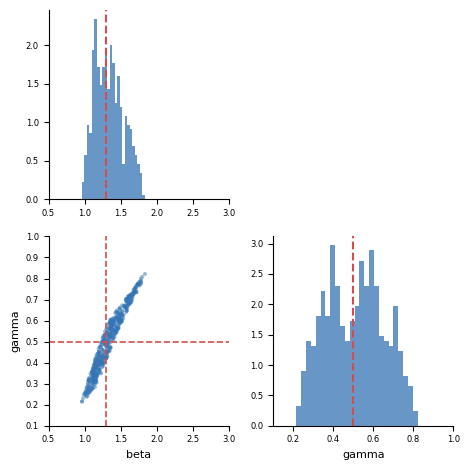

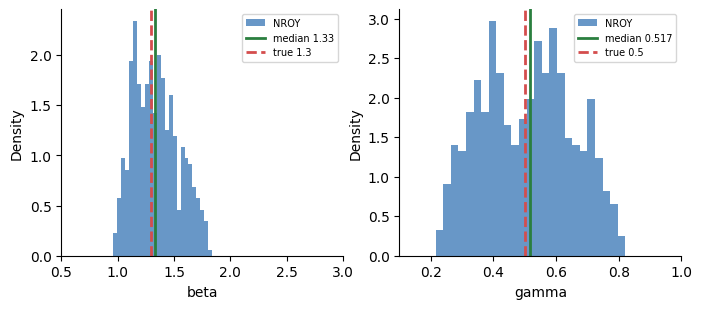

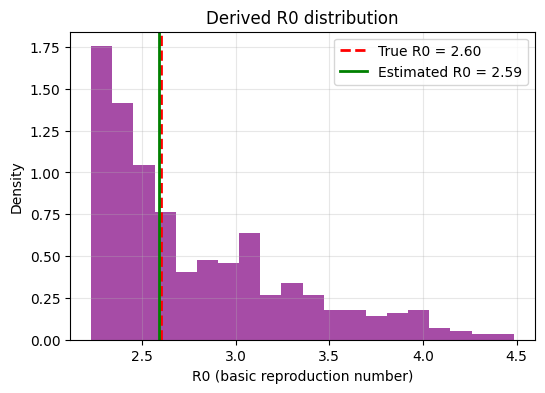

In [7]:
truth = {"beta": beta_true, "gamma": gamma_true}

# The plausible (NROY) parameter region, with the true values overlaid.
# engine.plot_nroy() replaces the hand-built scatter + marginal histograms.
engine.plot_nroy(truth=truth)
plt.show()

# Per-parameter posterior marginals (median + true value marked).
engine.plot_marginals(truth=truth)
plt.show()

# R0 = beta / gamma is a derived quantity specific to this SIR model, so we
# still plot it by hand.
R0_samples = final_samples["beta"] / final_samples["gamma"]
R0_true = beta_true / gamma_true
plt.figure(figsize=(6, 4))
plt.hist(R0_samples, bins=20, density=True, alpha=0.7, color="purple")
plt.axvline(R0_true, color="red", linestyle="--", linewidth=2, label=f"True R0 = {R0_true:.2f}")
plt.axvline(R0_samples.median(), color="green", linewidth=2,
            label=f"Estimated R0 = {R0_samples.median():.2f}")
plt.xlabel("R0 (basic reproduction number)")
plt.ylabel("Density")
plt.title("Derived R0 distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Validate Results with Forward Simulation

A quick sanity check: run the model at a handful of NROY parameter sets and overlay
the trajectories on the observed data.

For a more rigorous approach — weighting trajectories by pseudo-likelihood and
resampling to get a calibrated ensemble — see `05_trajectory_selection.ipynb`.

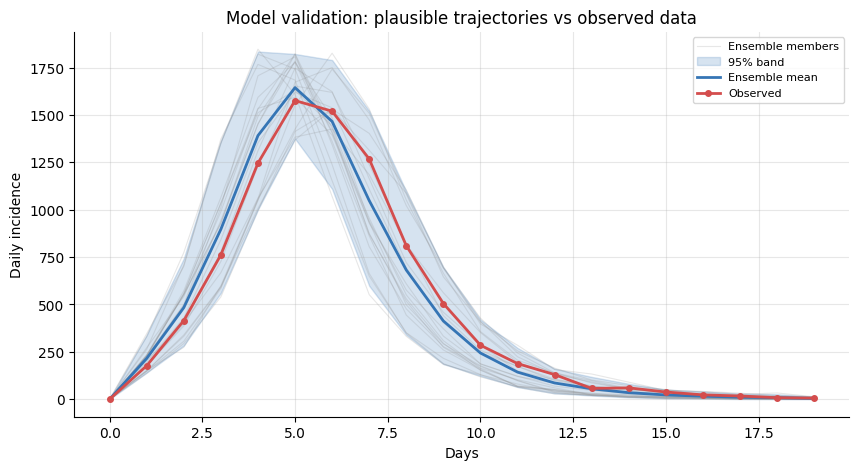

Mean RMSE: 150.2 +/- 72.8
Best RMSE: 36.2


In [8]:
n_runs = 20
idx = np.random.choice(len(final_samples), size=n_runs, replace=False)
validation_samples = final_samples.iloc[idx]

# Re-simulate at the plausible parameter sets, then let plot_ensemble_fan draw
# the spaghetti + mean + 95% band against the observed data.
trajectories = np.array([
    SIR(beta=row["beta"], gamma=row["gamma"],
        s0=population_size - n_seed_infections, i0=n_seed_infections).get_incidence()
    for _, row in validation_samples.iterrows()
])

hm.plot_ensemble_fan(trajectories, observed=incidence_obs.values,
                     xlabel="Days", ylabel="Daily incidence",
                     title="Model validation: plausible trajectories vs observed data")
plt.show()

rmse_values = [np.sqrt(np.mean((t - incidence_obs.values) ** 2)) for t in trajectories]
print(f"Mean RMSE: {np.mean(rmse_values):.1f} +/- {np.std(rmse_values):.1f}")
print(f"Best RMSE: {np.min(rmse_values):.1f}")

## Multiple Emulators Per Wave

By default feature selection (`builder.feature_selection`) uses automatic Fano-factor
selection capped at **one feature per wave**.  You can raise that cap — or specify
features explicitly — to train several emulators in a single wave.  Each emulator
targets one observable, and implausibility is computed per-emulator then maximised
across all of them, so a sample must pass *every* constraint simultaneously.

### Automated mode: raise the cap

```python
builder = hm.HistoryMatchingBuilder.from_data(parameter_bounds, observations)
builder.sampling_strategy = "lhs"
builder.emulator_type = "gpr"
builder.feature_selection = {"method": "fano", "max_features": 3}   # ← up to 3 per wave
builder.n_samples = 500
builder.max_iterations = 4
builder.implausibility_threshold = 3.0
builder.random_seed = 123
engine = builder.build()
engine.set_simulation_function(sir_simulation_function)
results = engine.run()
```

### Inspecting per-feature quality after `engine.run()`

`IterationResult.get_emulator_quality_metrics()` returns one entry per emulated
feature.  Use it to check whether each emulator was worth including:

In [9]:
print("Per-feature emulator quality across all waves:")

# result.quality_table() returns a tidy DataFrame; concatenate across waves.
quality = pd.concat([r.quality_table().assign(wave=r.iteration) for r in results])
quality.reset_index().set_index(["wave", "feature"])

Per-feature emulator quality across all waves:


,,r2,mse,n_train
wave,feature,,,
1,peak_incidence,0.995249,11033.517667,375
2,incidence_5,0.936069,7989.057549,375
3,total_cases,0.988483,5552.165165,375
4,incidence_5,0.797615,7262.862997,375


In the automated workflow there is no opportunity to drop a poor emulator mid-wave —
use the **manual workflow** (`02_manual_workflow.ipynb`) if you need to inspect
diagnostics and selectively drop emulators before committing each wave.

### Saving diagnostics to disk

Each `IterationResult` has a `save_diagnostics(fig_dir, all_results)` method that writes
per-feature predicted-vs-actual plots, ARD lengthscale charts (GPR only), a convergence
figure, and a `metrics.json` file:

In [10]:
import tempfile, os

diag_dir = tempfile.mkdtemp(prefix="hm_diagnostics_")
for result in results:
    result.save_diagnostics(diag_dir, all_results=results)

print(f"Diagnostics saved to {diag_dir}/")
for f in sorted(os.listdir(diag_dir)):
    print(f"  {f}")

Diagnostics saved to /tmp/claude-1000/hm_diagnostics_641vzwj1/
  wave1
  wave2
  wave3
  wave4


## Summary

This notebook demonstrated the **automated** history matching workflow:

1. **Model setup**: imported `SIR` and `generate_observed_data` from `model.py`
2. **Configuration**: used `HistoryMatchingBuilder` to define parameter bounds, observations, and
   emulator settings
3. **Execution**: called `engine.run()` to run all iterations automatically
4. **Analysis**: inspected the final plausible parameter space and validated against observed data

### Next steps

| Goal | Tutorial |
|------|----------|
| Manual step-by-step control with emulator inspection | `02_manual_workflow.ipynb` |
| Advanced builder options, callbacks, checkpointing | `03_advanced_configuration.ipynb` |
| Select specific `(parameter, seed)` trajectories from the NROY ensemble | `05_trajectory_selection.ipynb` |